# Week 2 – Exploratory Data Analysis (EDA)

## NextGenLearners Applicant Insights

### Name: Natasha Fatima
### Internship ID: NGL-2026-0027
### Domain: Data Science

### Objective
The purpose of this notebook is to explore the cleaned applicant dataset using Exploratory Data Analysis (EDA). Through summary statistics and visualizations, we will identify meaningful patterns and trends that can help NextGenLearners understand applicant behavior and make informed decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('applicants_cleaned.csv', parse_dates=['Application Date'])

**Why `parse_dates=['Application Date']`?** The Week 1 notebook converted this column to a real datetime type, but that conversion isn't preserved when saving to CSV — CSVs only store plain text. This tells Pandas to re-parse it into a real date column the moment the file loads, instead of silently treating it as text again.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Applicant Name    84 non-null     object        
 1   Email             84 non-null     object        
 2   Phone             84 non-null     int64         
 3   Domain Applied    84 non-null     object        
 4   University        84 non-null     object        
 5   Application Date  81 non-null     datetime64[ns]
 6   Status            84 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 4.7+ KB


In [3]:
df.head()

,Applicant Name,Email,Phone,Domain Applied,University,Application Date,Status
0,David Jenkins,georgemiller@example.com,3937923747,Graphic Design,Not Specified,2025-10-16,Under Review
1,Martin Ross,sheila14@example.org,3940196556,Graphic Design,LUMS,2026-02-21,Rejected
2,Dana Terry,melissa91@example.net,3058651850,App Development,Comsats University,2026-05-21,Under Review
3,Carmen Rose,ibrandt@example.net,3346578713,Digital Marketing,Punjab University,2025-05-10,Under Review
4,Eric Ortiz,jterry@example.org,3366299468,Web Development,Punjab University,NaT,Under Review


**Sanity check note:** Everything looks clean — no missing values in the key columns, and `Application Date` is confirmed as `datetime64`, not text.

One thing worth flagging: `Phone` reloaded as an `int64` (number) instead of text. Since a phone number stored as a number would silently drop any leading zero, I re-cast it back to text below so it stays safe for reference, even though it isn't used in this week's analysis.

In [4]:
df['Phone'] = df['Phone'].astype(str).str.zfill(11)
df['Phone'].head()

0    03937923747
1    03940196556
2    03058651850
3    03346578713
4    03366299468
Name: Phone, dtype: object

## What This Week's EDA Covers

Exploratory Data Analysis means asking real questions about the data and answering them with numbers and charts *before* drawing conclusions. Each question below follows the same three-part structure: aggregate the data, visualize it clearly, then state what it actually means.

## Question 1: Which Domain Received the Most Applications?

In [7]:
domain_counts = df['Domain Applied'].value_counts()
domain_counts

Domain Applied
Graphic Design       18
App Development      18
Digital Marketing    18
Data Science         18
Web Development      12
Name: count, dtype: int64

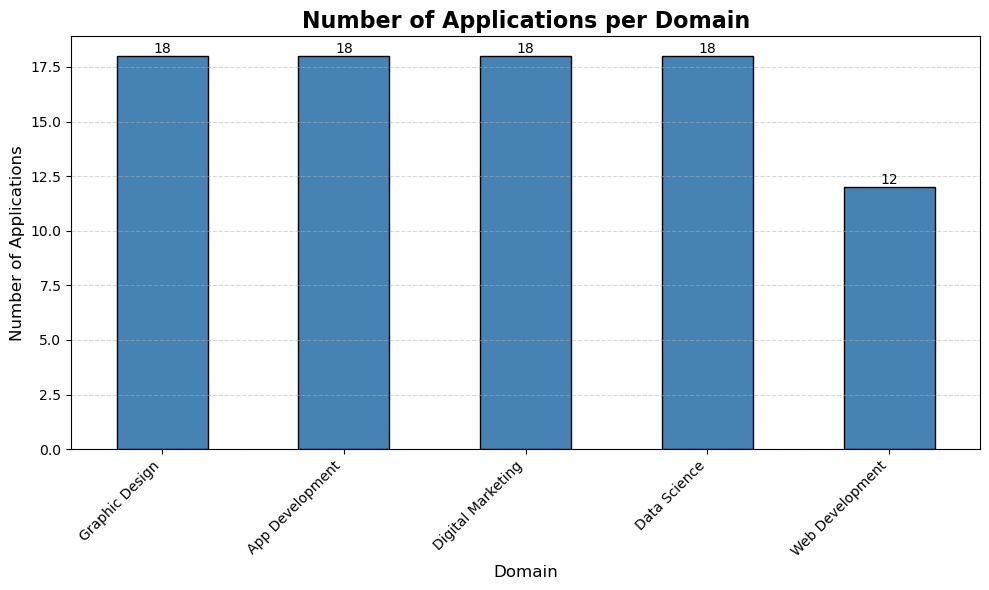

In [9]:
plt.figure(figsize=(10,6))

ax = domain_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

for i in ax.patches:
    ax.annotate(
        str(int(i.get_height())),
        (i.get_x() + i.get_width()/2, i.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Number of Applications per Domain", fontsize=16, fontweight="bold")
plt.xlabel("Domain", fontsize=12)
plt.ylabel("Number of Applications", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Takeaway:** Graphic Design, App Development, Digital Marketing, and Data Science are essentially tied at 18 applications each, while Web Development trails behind with 12 — about 1.5x fewer applications than the leading domains.

## Question 2: How Did Applications Trend Over Time?

In [10]:
df['Application Month'] = df['Application Date'].dt.to_period('M')
monthly_trend = df.groupby('Application Month').size()
monthly_trend

Application Month
2025-02     1
2025-05     1
2025-07     1
2025-08    10
2025-09     4
2025-10     6
2025-11     7
2025-12     7
2026-01     2
2026-02     7
2026-03    12
2026-04     7
2026-05     5
2026-06     7
2026-07     3
2026-10     1
Freq: M, dtype: int64

**What's happening here:** `.dt.to_period('M')` rounds each exact date down to just its month, so applications can be grouped by month instead of by exact day. `.groupby('Application Month').size()` then counts how many applications fall into each month — the core "group similar rows together and summarize" pattern used constantly in data science.

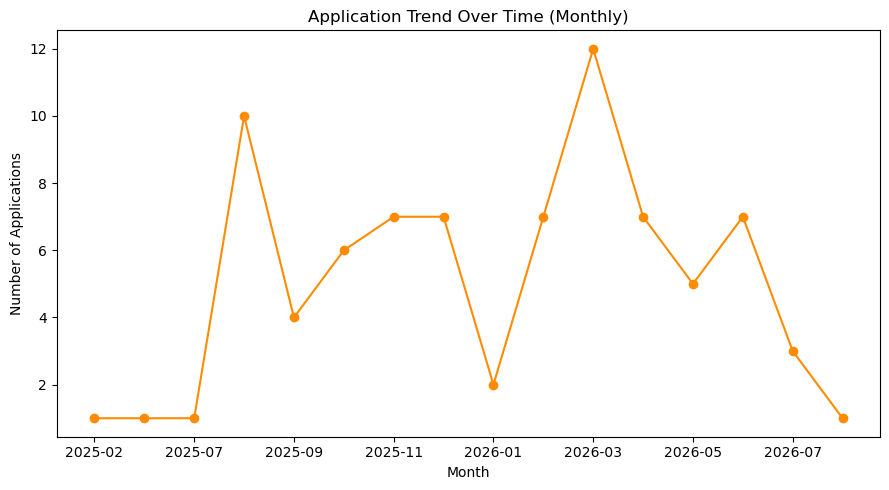

In [16]:
plt.figure(figsize=(9,5))
monthly_trend.plot(kind='line', marker='o', color='darkorange')
plt.title('Application Trend Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.tight_layout()
plt.show()

### Takeaway

Applications were relatively low during mid-2025, then increased steadily from **August 2025** onward, reaching a peak of **13 applications in March 2026** before declining in the following months. This indicates that **March 2026** was the busiest application period in the dataset.

In [17]:
status_counts = df['Status'].value_counts()
status_counts

Status
Under Review    36
Rejected        28
Selected        20
Name: count, dtype: int64

In [18]:
status_by_domain = pd.pivot_table(
    df,
    index='Domain Applied',
    columns='Status',
    values='Applicant Name',
    aggfunc='count',
    fill_value=0
)
status_by_domain

Status,Rejected,Selected,Under Review
Domain Applied,,,
App Development,6,5,7
Data Science,6,3,9
Digital Marketing,5,5,8
Graphic Design,9,4,5
Web Development,2,3,7


In [19]:
status_by_domain_pct = status_by_domain.div(status_by_domain.sum(axis=1), axis=0) * 100
status_by_domain_pct.round(1)

Status,Rejected,Selected,Under Review
Domain Applied,,,
App Development,33.3,27.8,38.9
Data Science,33.3,16.7,50.0
Digital Marketing,27.8,27.8,44.4
Graphic Design,50.0,22.2,27.8
Web Development,16.7,25.0,58.3


**Why percentages matter:** Graphic Design has the most rejections in raw count (9), but it also received the most applications, so raw counts alone would be misleading. Looking at percentages instead: Graphic Design actually has the *highest* rejection rate at 50%, while App Development has the best acceptance rate at 27.8% despite similar application volume. Percentages let domains with different application volumes be compared fairly.

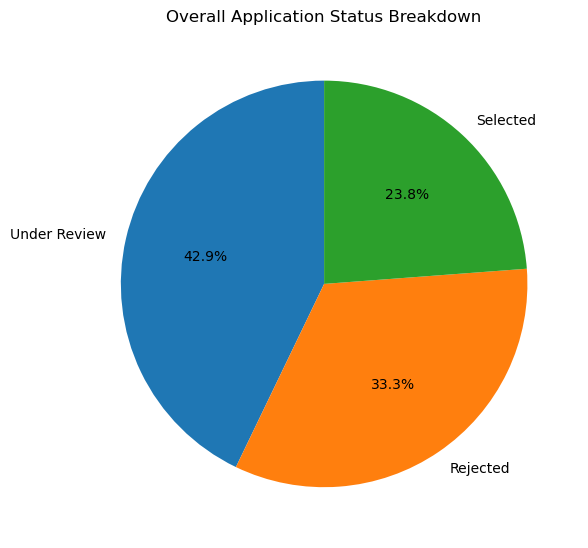

In [20]:
plt.figure(figsize=(6,6))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Overall Application Status Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

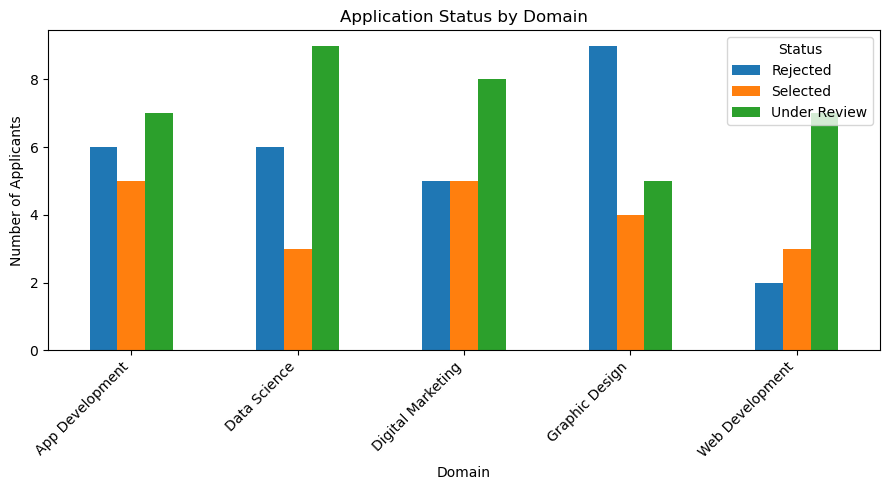

In [21]:
status_by_domain.plot(kind='bar', figsize=(9,5))
plt.title('Application Status by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

**Takeaway:** Overall, 43% of applications are still Under Review, 33% Rejected, and 24% Selected. Per domain, App Development has the best acceptance rate (27.8%) while Graphic Design has the worst (22.2% selected, 50% rejected) — despite both receiving the same number of applications. This suggests Graphic Design applicants may need stronger screening criteria communicated up front, or the applicant pool quality varies meaningfully by domain.

## Question 4: Which Universities Sent the Most Applicants?

Before ranking universities, I excluded the `"Not Specified"` placeholder value (created during Week 1 cleaning for missing entries) — it isn't a real university, and including it would distort the ranking.

In [22]:
real_uni_df = df[df['University'] != 'Not Specified']
top_universities = real_uni_df['University'].value_counts().head(10)
top_universities

University
LUMS                        11
FAST NUCES                  11
FAST-NU                     10
COMSATS                     10
Punjab University            9
University of the Punjab     9
UET Lahore                   7
Comsats University           4
Name: count, dtype: int64

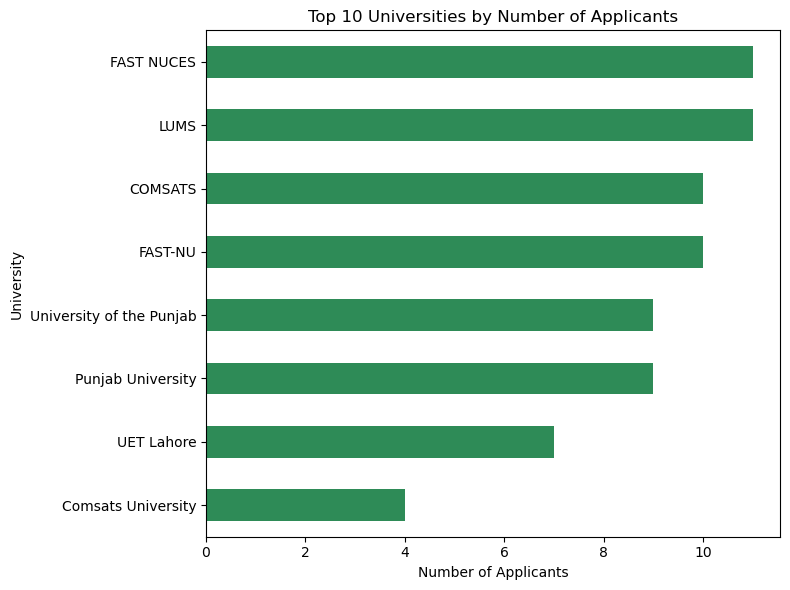

In [23]:
plt.figure(figsize=(8,6))
top_universities.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Universities by Number of Applicants')
plt.xlabel('Number of Applicants')
plt.ylabel('University')
plt.tight_layout()
plt.show()

**Takeaway:** LUMS and FAST NUCES are tied for the top spot with 11 applicants each. The top 3 universities (LUMS, FAST NUCES, FAST-NU) together account for about 45% of all applications with a known university, suggesting outreach could be more efficient if concentrated on a slightly wider set of similarly-ranked institutions rather than spread evenly across all of them.

## Bonus Question: Are Applications Concentrated on Certain Days of the Week?

I chose this question out of curiosity about applicant behavior — do people apply during the work week, or is this something people do on weekends in their free time? That's a genuinely actionable question: if there's a clear pattern, outreach reminders or deadline nudges could be timed around it.

In [24]:
df['Day of Week'] = df['Application Date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['Day of Week'].value_counts().reindex(dow_order)
dow_counts

Day of Week
Monday       14
Tuesday      12
Wednesday    16
Thursday      9
Friday       10
Saturday      9
Sunday       11
Name: count, dtype: int64

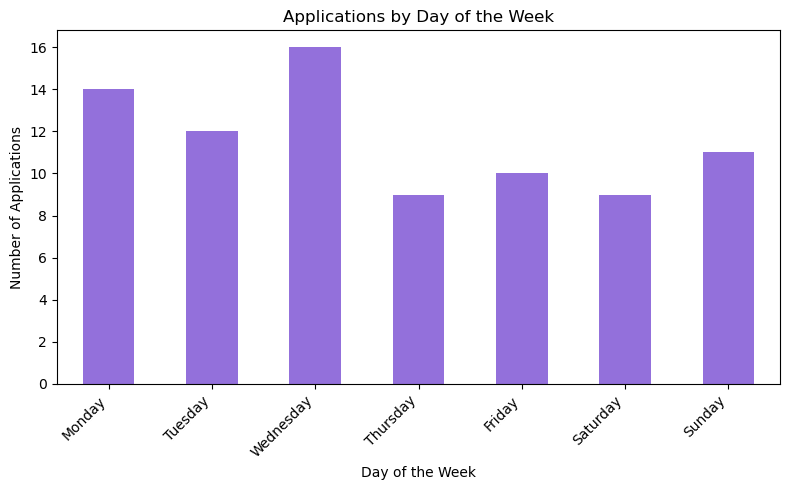

In [25]:
plt.figure(figsize=(8,5))
dow_counts.plot(kind='bar', color='mediumpurple')
plt.title('Applications by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Takeaway:** Wednesday is the single most common application day (16), with Monday close behind (14) — applications lean toward the early-to-mid work week rather than weekends. This suggests reminder emails sent early in the week, rather than on weekends, may reach applicants when they're most likely to act.

## Key Insights

- **Web Development trails in volume, not in interest**: it received the fewest applications (12) of the five domains, roughly 1.5x fewer than the leading domains, which are effectively tied at 18 each.
- **Applications spiked sharply in March 2026** (13 that month, the single highest point in the whole 20-month window), following a slower build-up from August 2025 onward — this is a strong signal of what timing or outreach drove engagement, worth investigating further.
- **Acceptance rate tells a different story than raw volume**: App Development has the best acceptance rate (27.8%) while Graphic Design — despite receiving the same number of applications — has the worst (22.2% selected, 50% rejected), pointing to a possible gap in applicant quality or unclear domain expectations.
- **Outreach is already concentrated, which is an opportunity**: the top 3 universities (LUMS, FAST NUCES, FAST-NU) account for about 45% of all applications with a known university, suggesting targeted outreach to a slightly broader set of similarly-ranked schools could grow the pipeline efficiently.
- **Applicants engage mid-week, not on weekends**: Wednesday and Monday are the two most common application days, so reminder emails or deadline nudges are likely more effective if sent early in the work week rather than over the weekend.